In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

print(os.getcwd())
tfrecordpath = "../Data/tfrecords/"


2025-02-06 18:20:46.193188: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738862446.203543   71003 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738862446.206603   71003 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-06 18:20:46.218096: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/mnt/c/Users/alexs/Desktop/levbot/Training


### Load in data
#### Define schema


In [2]:
def decode(record_bytes):
    # Function for parsing each record in the tf files
    example = tf.io.parse_single_example(
        # Data
        record_bytes,

        # Schema
        {
        'Timeframe': tf.io.FixedLenFeature([], tf.string),
        'timestamp': tf.io.RaggedFeature(dtype=tf.int64),
        'Open': tf.io.RaggedFeature(dtype=tf.float32),
        'High': tf.io.RaggedFeature(dtype=tf.float32),
        'Low': tf.io.RaggedFeature(dtype=tf.float32),
        'Close': tf.io.RaggedFeature(dtype=tf.float32),
        'Volume': tf.io.RaggedFeature(dtype=tf.float32),
        }
        )

    return example

In [3]:
def getDataset(path):
    ds = tf.data.TFRecordDataset(path,  num_parallel_reads = tf.data.AUTOTUNE)
    ds = ds.map(decode, num_parallel_calls = tf.data.AUTOTUNE)
    return ds



In [4]:
import TensorSlider

In [5]:
windowsize = 100
lookahead = 5
batchsize = 100

def slider():


    path = tfrecordpath + "BTCUSD_PERP/{tframe}.tfrecord"
    datasets = {"1m" : getDataset(path.format(tframe="1m")),
                "5m":  getDataset(path.format(tframe="5m")),
                "15m":  getDataset(path.format(tframe="15m")),
                "30m":  getDataset(path.format(tframe="30m")),
                "1h":  getDataset(path.format(tframe="1h"))}
    return TensorSlider.WindowSlider(datasets, windowsize, lookahead, batchsize=batchsize)

dataset = tf.data.Dataset.from_generator(slider, 
    output_signature=(
        tf.TensorSpec((batchsize, 5,5,windowsize), dtype=tf.float32),
        tf.TensorSpec((batchsize, 5, 5, lookahead+1), dtype=tf.float32))
    )

I0000 00:00:1738862449.093173   71003 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5592 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:05:00.0, compute capability: 8.6


In [6]:
# Testing slicing

ws = slider()
res = ws.__iter__().__next__()
data = tf.convert_to_tensor(res[1])
shape = data.shape
print(data.shape)

dividepricesby = tf.reshape(data[:,0,0,0], (shape[0], 1, 1, 1))
print(dividepricesby.shape)
prices = tf.divide(data[:,:,0:4], dividepricesby) # divide by latest base timeframe close
prices -= 1 # zero out
prices *= 10 # convert to 1/10 percentage, so 1 = 10 percent

low = tf.reduce_min(prices[:,0,2], 1)
high = tf.reduce_max(prices[:,0,1], 1)

label = tf.stack([low, high], axis = 1)
print(label.shape)

2025-02-06 18:20:49.352522: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:370] TFRecordDataset `buffer_size` is unspecified, default to 262144


(100, 5, 5, 6)
(100, 1, 1, 1)
(100, 2)


In [7]:
def createLabelsBatch(data, lookforward):
    """
    create input labels from the lookahead data
    """

    shape = lookforward.shape

    dividepricesby = tf.reshape(lookforward[:,0,0,0], (shape[0], 1, 1, 1))
    prices = tf.divide(lookforward[:,:,0:4], dividepricesby) # divide by latest base timeframe close
    prices -= 1 # zero out
    prices *= 10 # convert to 1/10 percentage, so 1 = 10 percent

    low = tf.reduce_min(prices[:,0,2], 1)
    high = tf.reduce_max(prices[:,0,1], 1)

    label = tf.stack([low, high], axis = 1)



    shape = data.shape
    # data processing, format: batch, timeframe, feature(ohlcv), window (ascending time)
    # prices
    dividepricesby = tf.reshape(data[:,0,3,-1], (shape[0], 1, 1, 1))
    prices = tf.divide(data[:,:,0:4], dividepricesby) # divide by latest base timeframe close
    prices -= 1 # zero out
    prices *= 10 # convert to 1/10 percentage, so 1 = 10 percent

    volumes = tf.reshape(data[:,:,4], (shape[0], shape[1], 1, shape[3]))
    dividebyvolume = tf.reshape(data[:,:,4,-1], (shape[0], shape[1], 1, 1))
    volume = tf.divide(volumes, dividebyvolume) # divide by latest volume (of each timeframe)
    volume -= 1
    volume *= 10 # convert to 1/10 percentage, so 1 = 10 percent

    data = tf.clip_by_value(tf.concat([prices, volume], axis=2), -2, 2)
    # remove nans
    data, label = tf.keras.ops.nan_to_num(data), tf.keras.ops.nan_to_num(label)

    return data, label

def decode(record_bytes):
    # Function for parsing each record in the tf files
    example = tf.io.parse_single_example(
        # Data
        record_bytes,

        # Schema
        {
        'Timeframe': tf.io.FixedLenFeature([], tf.string),
        'timestamp': tf.io.RaggedFeature(dtype=tf.int64),
        'Open': tf.io.RaggedFeature(dtype=tf.float32),
        'High': tf.io.RaggedFeature(dtype=tf.float32),
        'Low': tf.io.RaggedFeature(dtype=tf.float32),
        'Close': tf.io.RaggedFeature(dtype=tf.float32),
        'Volume': tf.io.RaggedFeature(dtype=tf.float32),
        }
        )

    return example

def getDataset(path):
    ds = tf.data.TFRecordDataset(path,  num_parallel_reads = tf.data.AUTOTUNE)
    ds = ds.map(decode, num_parallel_calls = tf.data.AUTOTUNE)
    return ds

In [8]:
def createLabels(data, lookforward):
    """
    create input labels from the lookaehad data
    """

    ohlc = lookforward
    ohlc /= ohlc[0,:] # divide by open price
    ohlc -= 1 # zero out
    ohlc *= 100 # convert to 1/10 percentage, so 1 = 10 percent
    ohlc = tf.clip_by_value(ohlc,-1,1)
    high = ohlc[tf.math.argmax(ohlc[:,1]), 1]
    low = ohlc[tf.math.argmin(ohlc[:,2]), 2]


    # same process, compute relative deltas
    processed = []
    latestClose = data[0,3,0] # base timeframe
    pricemult = 10 # 1 = 10 percent
    volmult = 0.1
    for i in range(0, data.shape[0]):
        # lets go timeframe by timeframe
        prices = tf.divide(data[i,0:4,:], latestClose) - 1
        prices = tf.multiply(prices, pricemult)
        volumes = tf.divide(data[i,4,:], data[i,4,0]) - 1
        volumes = tf.multiply(volumes, volmult)
        volumes = tf.expand_dims(volumes, 0)
        processed.append(tf.concat([prices, volumes], axis=0))

    datares = tf.clip_by_value(tf.stack(processed, axis=0), clip_value_min=-1, clip_value_max=1)

    # remove nans
    datares = tf.keras.ops.nan_to_num(datares)

    return tf.expand_dims(datares,0), [low, high]

In [9]:
def printtimeframe(features):
    # batch, timeframe, feature
    batch = features[0]
    print(batch[0, 0])
    #plt.plot(batch[0, 0])
    print(batch.shape)
    for i in range(0, batch.shape[0]):
        plt.plot(batch[i, 3])
        #plt.show()
    plt.show()

Time taken for 102 calls: 0.177077054977417s, thats 1.74ms per call
tf.Tensor(
[-0.00450611 -0.00728667 -0.00977874 -0.00862777 -0.00901163 -0.01112103
  0.01179099  0.00843644  0.00546455  0.01457214  0.01006603  0.01073718
  0.00977874  0.0136137   0.02099395  0.01840591  0.01725554  0.01111984
  0.02243161  0.01073718  0.01198292  0.01064062  0.00479341  0.00335574
  0.00268459  0.00239611  0.00230074  0.00239611  0.00249267  0.0050807
  0.00239611 -0.00191748 -0.00201404 -0.00230134 -0.00421822 -0.00335515
 -0.00412226  0.         -0.00441015  0.0013411   0.00412226  0.01025796
  0.01878977  0.03096461  0.03642917  0.02741694  0.02502084  0.02454162
  0.02041936  0.02329588  0.02444625  0.01811862  0.01783133  0.03048539
  0.02741694  0.02559662  0.03048539  0.02962232  0.03144383  0.03058076
  0.02808809  0.02760887  0.02712965  0.02578735  0.02617121  0.02578735
  0.02818465  0.0291431   0.02492547  0.02530813  0.01811862  0.01111984
  0.01035333  0.00987411  0.00996947  0.014572

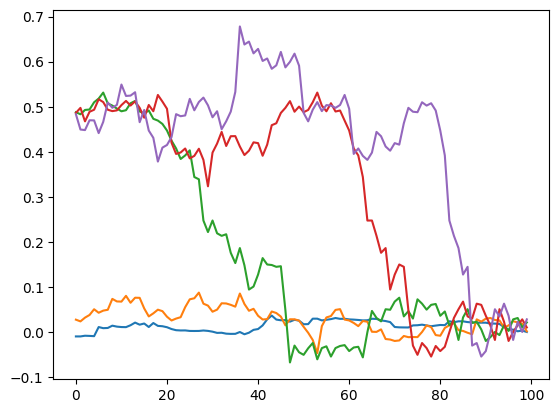

In [12]:
iterate_over = dataset.map(createLabelsBatch)

import time
t0 = None
for i, data in enumerate(iterate_over):
    if np.any((tf.math.is_nan(data[0]))):
        print("NaN in data")
    if i == 0:
        t0 = time.time()
    if i > 100:
        tdelta = time.time() - t0
        print(f"Time taken for {i+1} calls: {tdelta}s, thats {((tdelta/(i+1))*1000):.2f}ms per call")
        printtimeframe(data[0])
        break
        

In [11]:
import keras
path = "models/modeltest/model.keras"
model = keras.models.load_model(path)
history = model.fit(dataset.map(createLabels),
                        epochs=1, verbose=1,
                        validation_data=None, callbacks=None)

/root/miniconda3/envs/levbot/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 34 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


ValueError: in user code:

    File "/tmp/ipykernel_71003/1002610640.py", line 11, in createLabels  *
        high = ohlc[tf.math.argmax(ohlc[:,1]), 1]

    ValueError: Shapes must be equal rank, but are 2 and 0
    	From merging shape 0 with other shapes. for '{{node strided_slice_2/stack_1}} = Pack[N=2, T=DT_INT64, axis=0](ArgMax, strided_slice_2/stack_1/values_1)' with input shapes: [5,6], [].
